In [3]:
import numpy as np
d = np.array([1/2,1/2,1/2])/2/225*0.35
Nmax = np.array([53,44,38])
d = d/Nmax
d*2

array([1.46750524e-05, 1.76767677e-05, 2.04678363e-05])

(2171, 3)

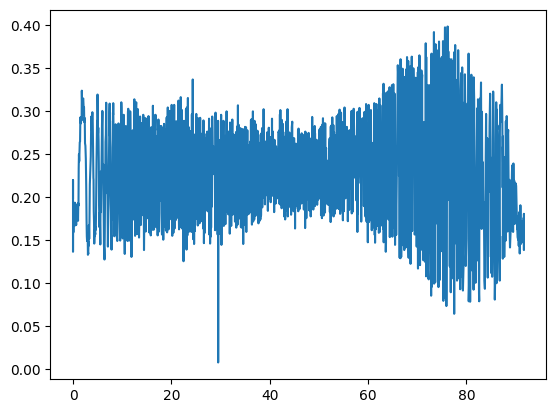

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
df =pd.read_csv("MS Messung1.csv")
data1 = df.to_numpy()
plt.figure()
data1[:,2] = data1[:,2]/data1[-225,2]*90
start = 0
end = -1
plt.plot(data1[start:end,2],data1[start:end,1])
# plt.plot(data1[:end,2],np.mean(data1[:end,1])*np.ones(end))
# plt.plot(data1[:end,2],0.243*np.ones(end))
plt.show()

In [143]:
end =900

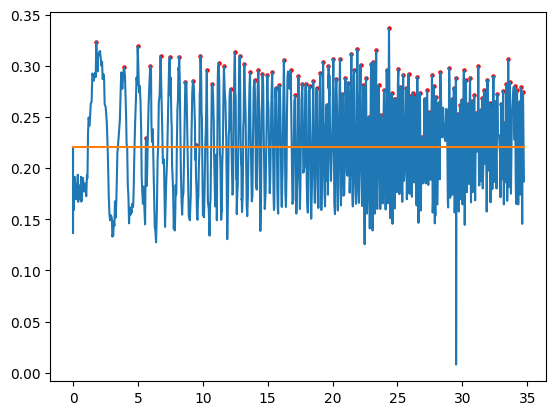

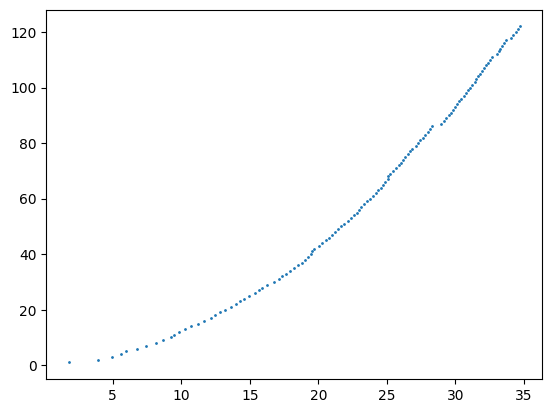

In [144]:

start =0
m = np.mean(data1[:end,1])
indices = []

for i in range(start,end):
    if (data1[i-1,1]<=m and data1[i,1]>m) or (data1[i-1,1]>=m and data1[i,1]<m):
        indices.append(i)
maxima_pos = []
maxima = []
for j in range(0,len(indices)-1,2):
    maxi = np.max(data1[indices[j]:indices[j+1],1])
    pos = data1[list(data1[indices[j]:indices[j+1],1]).index(maxi)+indices[j],2]
    maxima_pos.append(pos)
    maxima.append(maxi)
numb = np.arange(1,len(maxima_pos)+1)
plt.figure()
plt.plot(data1[start:end,2],data1[start:end,1])
plt.scatter(maxima_pos,maxima,s=5,color='red')
# plt.scatter(data1[indices,2],data1[indices,1],s=5,color='green')
plt.plot(data1[start:end,2],np.ones(end-start)*m)
plt.show()
plt.figure()
plt.scatter(maxima_pos,numb,s=1)
plt.show()



/tmp/ipykernel_851618/273855135.py:6: RuntimeWarning: invalid value encountered in sqrt
  cosbeta = np.sqrt(n**2-np.sin(alpha-d)**2)


  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.15695995375323546
        x: [ 1.697e+00  6.395e+02  8.950e+02 -7.001e-02]
      nit: 221
      jac: [ 1.995e-01  2.240e-04 -2.244e-04 -3.560e-02]
     nfev: 1450
     njev: 290
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

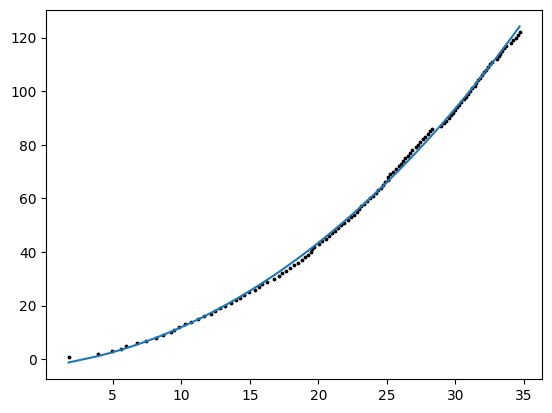

In [147]:
numb = np.array(numb)
maxima_pos = np.array(maxima_pos)

def fit_glas(alpha,n,b,c,d):
    lam = 550
    cosbeta = np.sqrt(n**2-np.sin(alpha-d)**2)
    return 2*b*(cosbeta-(1)*np.cos(alpha-d))-c
def glas_wrap(p):
    return np.sum((numb-fit_glas(maxima_pos/180*np.pi,*p))**2)/end
from scipy.optimize import minimize
opt = {'maxiter':10**5}
min_res = minimize(glas_wrap,[1.6,200,900,0],bounds=[(0.5,90),(0,10**8),(-np.inf,np.inf),(-np.pi/2,np.pi/2),])#,method='Nelder-Mead',options=opt)
plt.figure()
plt.plot(maxima_pos,fit_glas(maxima_pos/180*np.pi,*min_res.x))
plt.scatter(maxima_pos,numb,s=3,color='0')
min_res